<a href="https://colab.research.google.com/github/datadigger01/AppStatMat/blob/main/AssociationRule_Apriori_ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Association Rule

In [2]:
#To make sure the first row is not thought of as the heading

df = pd.read_csv('https://raw.githubusercontent.com/datadigger01/AppStatMat/main/Data/Market_Basket_Opt.csv', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       7501 non-null   object
 1   1       5747 non-null   object
 2   2       4389 non-null   object
 3   3       3345 non-null   object
 4   4       2529 non-null   object
 5   5       1864 non-null   object
 6   6       1369 non-null   object
 7   7       981 non-null    object
 8   8       654 non-null    object
 9   9       395 non-null    object
 10  10      256 non-null    object
 11  11      154 non-null    object
 12  12      87 non-null     object
 13  13      47 non-null     object
 14  14      25 non-null     object
 15  15      8 non-null      object
 16  16      4 non-null      object
 17  17      4 non-null      object
 18  18      3 non-null      object
 19  19      1 non-null      object
dtypes: object(20)
memory usage: 1.1+ MB


In [4]:
#Transforming the list into a list of lists, so that each transaction can be indexed easier
transactions = []
for i in range(0, df.shape[0]):
    transactions.append([str(df.values[i, j]) for j in range(0, 20)])

print(transactions[1])

['burgers', 'meatballs', 'eggs', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan']


### Association Rule 수행을 위한 package 설치 - Apriori

In [5]:
!pip install apyori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=e321ef7a7474da00f9a583190bc6dcda08754b578b21789b5375f33b08d48245
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


### Apriori 알고리즘 수행하여 rule 도출

In [24]:
from apyori import apriori
# Please download this as a custom package --> type "apyori"

rules = apriori(transactions, min_support = 0.003, min_confidence = 0.2, min_lift = 2, min_length = 2)
# Support: number of transactions containing set of times / total number of transactions
# .      --> products that are bought at least 3 times a day --> 21 / 7501 = 0.0027
# Confidence: Should not be too high, as then this wil lead to obvious rules

#viewing the rules
results = list(rules)

In [25]:
results[0:5]

[RelationRecord(items=frozenset({'almonds', 'burgers'}), support=0.005199306759098787, ordered_statistics=[OrderedStatistic(items_base=frozenset({'almonds'}), items_add=frozenset({'burgers'}), confidence=0.25490196078431376, lift=2.923577382023146)]),
 RelationRecord(items=frozenset({'bacon', 'spaghetti'}), support=0.003199573390214638, ordered_statistics=[OrderedStatistic(items_base=frozenset({'bacon'}), items_add=frozenset({'spaghetti'}), confidence=0.36923076923076925, lift=2.1206738131699847)]),
 RelationRecord(items=frozenset({'milk', 'black tea'}), support=0.004266097853619517, ordered_statistics=[OrderedStatistic(items_base=frozenset({'black tea'}), items_add=frozenset({'milk'}), confidence=0.29906542056074764, lift=2.3079112341833006)]),
 RelationRecord(items=frozenset({'blueberries', 'spaghetti'}), support=0.0034662045060658577, ordered_statistics=[OrderedStatistic(items_base=frozenset({'blueberries'}), items_add=frozenset({'spaghetti'}), confidence=0.37681159420289856, lift=2

In [26]:
# Function to extract details from the apriori results
def inspect_apriori_results(results):
    rh_list = [] # Right Hand Side
    lh_list = [] # Left Hand Side
    support_values = []
    confidence = []
    lift = []

    # Iterate through each RelationRecord in the results list
    for relation_record in results:
        # Access support directly from the RelationRecord
        current_support = relation_record.support

        # Each RelationRecord can have multiple OrderedStatistic objects
        for ordered_stat in relation_record.ordered_statistics:
            lh_list.append(tuple(ordered_stat.items_base))
            rh_list.append(tuple(ordered_stat.items_add))
            support_values.append(current_support)
            confidence.append(ordered_stat.confidence)
            lift.append(ordered_stat.lift)

    return lh_list, rh_list, support_values, confidence, lift

# Extract the data
lhs, rhs, supports, confidences, lifts = inspect_apriori_results(results)

# Create the result_df DataFrame
result_df = pd.DataFrame({
    'LHS': lhs,
    'RHS': rhs,
    'Support': supports,
    'Confidence': confidences,
    'Lift': lifts
})

# Display the first few rows of the created DataFrame
print("Created result_df (first 5 rows):")
print(result_df.head())

# Filter out rules containing 'nan' as they are not meaningful for further analysis or visualization
result_df_cleaned = result_df[~result_df['LHS'].apply(lambda x: 'nan' in str(x))]
result_df_cleaned = result_df_cleaned[~result_df_cleaned['RHS'].apply(lambda x: 'nan' in str(x))]

# You can also display the first few rows of the cleaned DataFrame
print("\nCleaned result_df (first 5 rows - 'nan' removed):")
print(result_df_cleaned.head())

Created result_df (first 5 rows):
              LHS              RHS   Support  Confidence      Lift
0      (almonds,)       (burgers,)  0.005199    0.254902  2.923577
1        (bacon,)     (spaghetti,)  0.003200    0.369231  2.120674
2    (black tea,)          (milk,)  0.004266    0.299065  2.307911
3  (blueberries,)     (spaghetti,)  0.003466    0.376812  2.164214
4   (body spray,)  (french fries,)  0.004266    0.372093  2.177122

Cleaned result_df (first 5 rows - 'nan' removed):
              LHS              RHS   Support  Confidence      Lift
0      (almonds,)       (burgers,)  0.005199    0.254902  2.923577
1        (bacon,)     (spaghetti,)  0.003200    0.369231  2.120674
2    (black tea,)          (milk,)  0.004266    0.299065  2.307911
3  (blueberries,)     (spaghetti,)  0.003466    0.376812  2.164214
4   (body spray,)  (french fries,)  0.004266    0.372093  2.177122


In [27]:
result_df_cleaned.sort_values(by='Confidence', ascending=False)

,LHS,RHS,Support,Confidence,Lift
1067,"(milk, soup, frozen vegetables)","(mineral water,)",0.003066,0.766667,3.216312
1061,"(milk, olive oil, frozen vegetables)","(mineral water,)",0.003333,0.694444,2.913326
110,"(cereals, ground beef)","(spaghetti,)",0.003066,0.676471,3.885303
1008,"(milk, ground beef, frozen vegetables)","(mineral water,)",0.003733,0.651163,2.731752
315,"(soup, frozen vegetables)","(mineral water,)",0.005066,0.633333,2.656954
...,...,...,...,...,...
723,"(eggs, ground beef)","(chocolate, mineral water)",0.003999,0.200000,3.797975
70,"(eggs, ground beef)","(burgers,)",0.003999,0.200000,2.293884
374,"(low fat yogurt, mineral water)","(ground beef,)",0.004799,0.200000,2.035550
1126,"(shrimp, frozen vegetables)","(spaghetti, mineral water)",0.003333,0.200000,3.348661


In [30]:
result_df_cleaned.sort_values(by='Lift', ascending=False)

,LHS,RHS,Support,Confidence,Lift
1064,"(soup, frozen vegetables)","(milk, mineral water)",0.003066,0.383333,7.987176
1059,"(olive oil, frozen vegetables)","(milk, mineral water)",0.003333,0.294118,6.128268
496,"(whole wheat pasta, mineral water)","(olive oil,)",0.003866,0.402778,6.115863
1065,"(milk, soup)","(frozen vegetables, mineral water)",0.003066,0.201754,5.646864
427,"(tomato sauce,)","(spaghetti, ground beef)",0.003066,0.216981,5.535971
...,...,...,...,...,...
125,"(chicken, french fries)","(spaghetti,)",0.003866,0.349398,2.006762
13,"(extra dark chocolate,)","(mineral water,)",0.005733,0.477778,2.004369
254,"(ground beef, french fries)","(milk,)",0.003600,0.259615,2.003472
156,"(escalope, mineral water)","(chocolate,)",0.005599,0.328125,2.002657


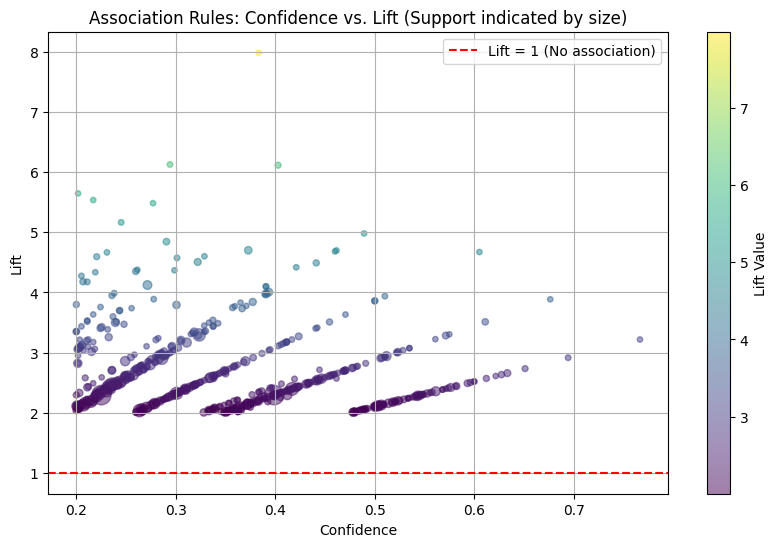

In [31]:
# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(result_df_cleaned['Confidence'], result_df_cleaned['Lift'],
            s=result_df_cleaned['Support']*5000, # Scale support for better visibility
            alpha=0.5,
            c=result_df_cleaned['Lift'], # Color by lift
            cmap='viridis') # Choose a colormap

plt.title('Association Rules: Confidence vs. Lift (Support indicated by size)')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.colorbar(label='Lift Value')
plt.grid(True)
plt.axhline(y=1, color='r', linestyle='--', label='Lift = 1 (No association)')
plt.legend()
plt.show()